# 1. Project Overview

## Problem Statement
Customer churn is one of the most critical challenges for telecommunications companies. When customers leave for a competitor, the company loses recurring revenue and must spend significantly more to acquire new customers than to retain existing ones. Predicting which customers are likely to churn allows companies to intervene with targeted retention strategies.
This project builds a complete ETL (Extract, Transform, Load) pipeline using Apache Spark to process the Telco Customer Churn dataset from Kaggle. The pipeline extracts raw customer data, applies a comprehensive series of transformations to clean and engineer features, and loads the processed data into an efficient storage format ready for downstream machine learning.

## 2. About the Dataset

* Dataset: Telco Customer Churn (IBM sample dataset)
* Purpose: Predict whether a telecom customer will leave the service (churn).
* Size: 7,043 customers with 21 features.
* Target Variable: Churn – indicates if the customer left within the last month.
* Feature Categories:
    * Services: phone service, internet service, online security, backup, device protection, tech support, streaming TV/movies.
    * Account Information: tenure, contract type, payment method, paperless billing, monthly charges, total charges.
    * Demographics: gender, senior citizen status, partner, dependents.
* Use Case: Commonly used for customer churn prediction and retention analysis in machine learning.

In [ ]:
# Initialize Spark Session
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TelcoChurnExploration") \
    .master("local[*]") \
    .getOrCreate()

print(f"Spark Version: {spark.version}")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/13 10:33:00 WARN Utils: Your hostname, Orbins-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.41 instead (on interface en0)
26/03/13 10:33:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/13 10:33:10 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark Version: 4.1.1


In [ ]:
# Load the Dataset
df = spark.read.csv("File:///Users/orbin/Documents/GitHub/Machine_Learning/Data-Engineering/Customer-Churn-Project/spark-etl-pipeline/data/raw/Telco-Customer-Churn.csv",
                    header=True, inferSchema=True)
print(f"Rows: {df.count()}, Columns: {len(df.columns)}")

Rows: 7043, Columns: 21


In [ ]:
# Inspect Schema
df.printSchema()
df.show(5, truncate=False)

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = true)

+----------+------+-------------+-------+----------+------+------------+---------

In [ ]:
# Summary Statistics
df.describe().show()

26/03/13 20:03:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+----------+------+------------------+-------+----------+------------------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+------------------+------------------+-----+
|summary|customerID|gender|     SeniorCitizen|Partner|Dependents|            tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|      Contract|PaperlessBilling|       PaymentMethod|    MonthlyCharges|      TotalCharges|Churn|
+-------+----------+------+------------------+-------+----------+------------------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------------+----------------+--------------------+------------------+------------------+-----+
|  count|      7043|  7043|              7043|   7043|      7043|     

In [8]:
# Check for Missing Values
from pyspark.sql.functions import col, sum as spark_sum, isnan, when
from pyspark.sql.types import DoubleType, IntegerType

missing_df = df.select([
    spark_sum(
        when(
            col(c).isNull() | (isnan(col(c)) if dict(df.dtypes)[c] in ["double","int"] else False),
            1
        ).otherwise(0)
    ).alias(c)
    for c in df.columns
])

missing_df.show()


+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|              0|       0|               0| 

+-----+-----+
|Churn|count|
+-----+-----+
|   No| 5174|
|  Yes| 1869|
+-----+-----+



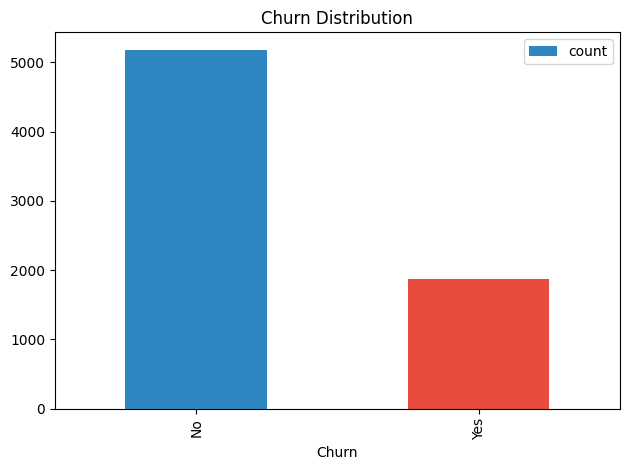

In [ ]:
# Target Variable Distribution
df.select("Churn").groupBy("Churn").count().show()


# Convert to Pandas for visualization
import matplotlib.pyplot as plt


churn_counts = df.select("Churn").groupBy("Churn").count().toPandas()
churn_counts.plot(kind="bar", x="Churn", y="count",
                  color=["#2E86C1", "#E74C3C"],
                  title="Churn Distribution")
plt.tight_layout()
plt.show()


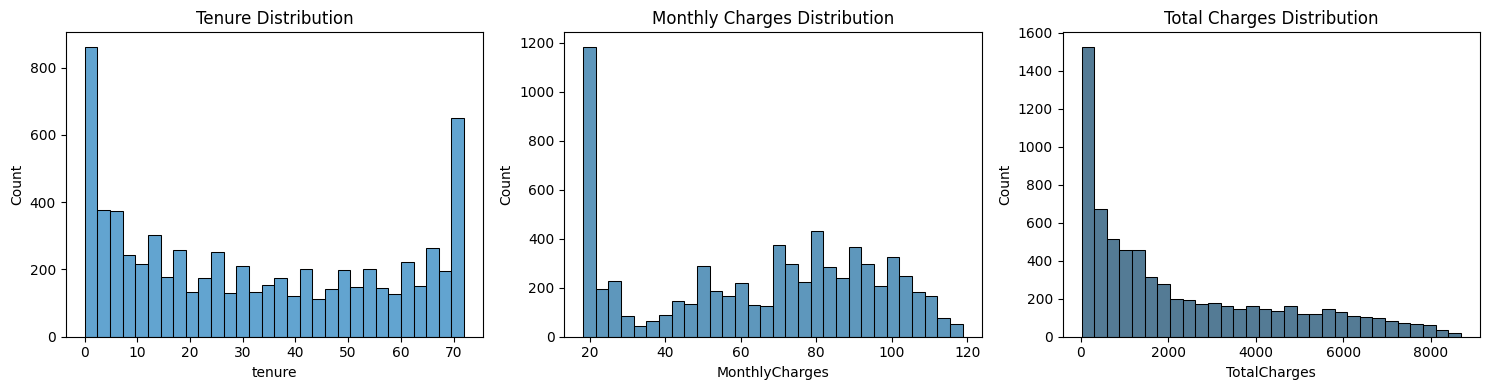

In [12]:
# Feature Distributions
import seaborn as sns
import pandas as pd

pdf = df.toPandas()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


sns.histplot(pdf["tenure"], bins=30, ax=axes[0], color="#2E86C1")
axes[0].set_title("Tenure Distribution")


sns.histplot(pdf["MonthlyCharges"], bins=30, ax=axes[1], color="#2874A6")
axes[1].set_title("Monthly Charges Distribution")


# Convert TotalCharges to numeric for plotting
pdf["TotalCharges"] = pd.to_numeric(pdf["TotalCharges"], errors="coerce")
sns.histplot(pdf["TotalCharges"].dropna(), bins=30, ax=axes[2], color="#1B4F72")
axes[2].set_title("Total Charges Distribution")


plt.tight_layout()
plt.show()

In [13]:
# Stop Spark Session
spark.stop()

In [3]:
import pandas as pd 

df = pd.read_csv('/Users/orbin/Documents/GitHub/Machine_Learning/Data-Engineering/Customer-Churn-Project/spark-etl-pipeline/data/raw/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
